In [1]:
import numpy as np
from zfish._io import import16chFlt
import matplotlib.pyplot as plt
from tqdm import tqdm
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import *

code_id = "5004 - Open Field 2D"
loc = join(figpath, code_id)
mkdir(loc)

f_op = pd.read_excel(r"D:\EnData\Experiment Records.xlsx", sheet_name='Open Field')
print(len(f_op))
pass

        D:\Yao Shuyang\En Lab\Results\5004 - Open Field 2D is already existed!
6


In [ ]:
traj_dir = join(loc, "Trajectories")
mkdir(traj_dir)

def visualize_traj(i: int):
    res = import16chFlt(f_op['Ephys path'][i])
    t = res['behav_time']
    idx = np.where(t > 6)[0]
    for k in res.keys():
        res[k] = res[k][idx]
    pos_x, pos_y = res['behav_pos_x'], res['behav_pos_y']
    t = res['behav_time']
    
    fig = plt.figure(figsize=(4, 4))
    ax = plt.axes()
    ax.plot(
        pos_x, 
        pos_y, 
        color='k', linewidth=0.5
    )
    ax.set_xlabel('Position X')
    ax.set_ylabel('Position Y')
    ax.set_title(f'Trajectory - Fish {f_op["ID"][i]}, T = {t[-1] - t[0]:.2f}s')
    plt.savefig(join(traj_dir, f'{f_op["ID"][i]}.png'))
    plt.savefig(join(traj_dir, f'{f_op["ID"][i]}.svg'))
    plt.close(fig)
    
for i in tqdm(range(len(f_op))):
    visualize_traj(i)

        D:\Yao Shuyang\En Lab\Results\5004 - Open Field 2D\Trajectories is already existed!


  0%|          | 0/6 [00:00<?, ?it/s]

dict_keys(['behav_time', 'ch0', 'ch1', 'fltCh0', 'fltCh1', 'n_trials', 'behav_pos_x', 'behav_pos_y', 'in_trial_time', 'behav_speed_x', 'behav_speed_y', 'behav_orient', 'opto_states', 'Paradigm', 'Stim Type', 'pass_speed', 'swim_gain', 'swim_speed', 'turn_gain'])


 17%|█▋        | 1/6 [00:03<00:17,  3.41s/it]

dict_keys(['behav_time', 'ch0', 'ch1', 'fltCh0', 'fltCh1', 'n_trials', 'behav_pos_x', 'behav_pos_y', 'in_trial_time', 'behav_speed_x', 'behav_speed_y', 'behav_orient', 'opto_states', 'Paradigm', 'Stim Type', 'pass_speed', 'swim_gain', 'swim_speed', 'turn_gain'])


...

 67%|██████▋   | 4/6 [00:37<00:19,  9.52s/it]

dict_keys(['behav_time', 'ch0', 'ch1', 'fltCh0', 'fltCh1', 'n_trials', 'behav_pos_x', 'behav_pos_y', 'in_trial_time', 'behav_speed_x', 'behav_speed_y', 'behav_orient', 'opto_states', 'Paradigm', 'Stim Type', 'pass_speed', 'swim_gain', 'swim_speed', 'turn_gain'])


 83%|████████▎ | 5/6 [00:42<00:08,  8.00s/it]

dict_keys(['behav_time', 'ch0', 'ch1', 'fltCh0', 'fltCh1', 'n_trials', 'behav_pos_x', 'behav_pos_y', 'in_trial_time', 'behav_speed_x', 'behav_speed_y', 'behav_orient', 'opto_states', 'Paradigm', 'Stim Type', 'pass_speed', 'swim_gain', 'swim_speed', 'turn_gain'])


100%|██████████| 6/6 [00:44<00:00,  7.49s/it]


# Angular Speed vs. Swim Power

In [4]:
angular_dir = join(loc, "Angular Velocity")
mkdir(angular_dir)

def angular_velocity(i):
    res = import16chFlt(f_op['Ephys path'][i])
    t = res['behav_time']
    hd = res['behav_orient']
    dhd = np.diff(hd)
    dhd[dhd > np.pi] = 2 * np.pi - dhd[dhd > np.pi]
    dhd[dhd < -np.pi] = -2 * np.pi - dhd[dhd < -np.pi]
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 6))
    idx = np.where(np.abs(dhd) > 1e-8)[0]
    axes[0].plot(t[:-1][idx], hd[:-1][idx], color='k', linewidth=0.5, label='Head Direction')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Head Direction\n(radians)')
    axes[0].set_title(f'Head Direction and Angular Velocity - Fish {f_op["ID"][i]}')
    axt = axes[0].twinx()
    axt.set_ylabel('Angular Velocity\n(radians/frame)', color='r')
    axt.plot(t[:-1][idx], dhd[idx], color='r', linewidth=0.5)
    axt.set_ylim(-np.pi/9, np.pi/9)
    axt.spines['right'].set_color('r')
    axes[1].hist(np.rad2deg(dhd[idx]), bins=40, range=(-20, 20), density=True)
    axes[1].set_title(f'Angular Velocity - Fish {f_op["ID"][i]}')
    axes[1].set_xlabel('Angular Velocity\n(degrees/frame)')
    axes[1].set_ylabel('PDF')
    plt.tight_layout()
    plt.savefig(join(angular_dir, f'{f_op["ID"][i]}.png'))
    plt.savefig(join(angular_dir, f'{f_op["ID"][i]}.svg'))
    plt.close()
    
for i in tqdm(range(len(f_op))):
    angular_velocity(i)

        D:\Yao Shuyang\En Lab\Results\5004 - Open Field 2D\Angular Velocity is already existed!


100%|██████████| 6/6 [00:33<00:00,  5.63s/it]


7.42023439021456e-06 0.0002929433614991465
-0.003200181797209393


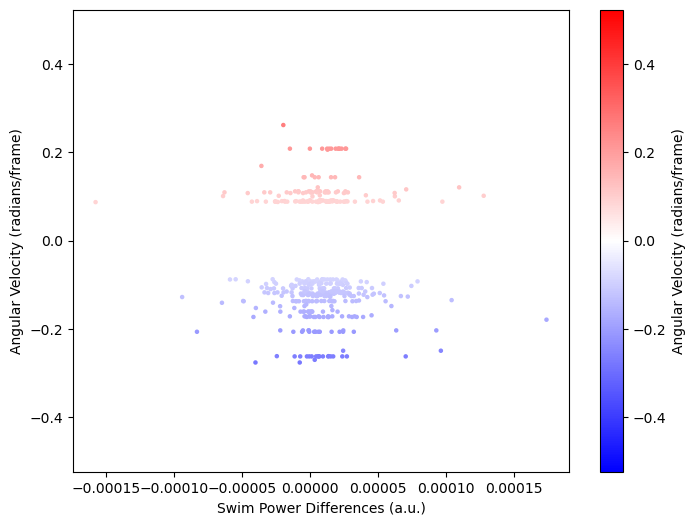

In [14]:
def turn_vs_swim(i):
    res = import16chFlt(f_op['Ephys path'][i])
    idx = np.where(res['behav_time'] > 6)[0]
    for k in res.keys():
        res[k] = res[k][idx]
        
    hd = res['behav_orient']
    dhd = np.diff(hd)
    dhd[dhd > np.pi] = 2 * np.pi - dhd[dhd > np.pi]
    dhd[dhd < -np.pi] = -2 * np.pi - dhd[dhd < -np.pi]
    
    t = res['behav_time']
    turn_moment = np.where(np.abs(dhd) > np.deg2rad(10))[0]
    ch0 = res['fltCh0']
    ch1 = res['fltCh1']
    print(np.min(ch0), np.max(ch0))
    
    idx = np.where(np.abs(dhd) > np.deg2rad(5))[0]
    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes()
    sc = ax.scatter(
        ch0[idx] - ch1[idx],
        dhd[idx],
        c=dhd[idx], 
        cmap='bwr', 
        s=5, 
        vmin=-np.deg2rad(30), 
        vmax=np.deg2rad(30)
    )
    plt.colorbar(sc, label='Angular Velocity (radians/frame)')
    ax.set_xlabel('Swim Power Differences (a.u.)')
    ax.set_ylabel('Angular Velocity (radians/frame)')
    ax.set_ylim(-np.deg2rad(30), np.deg2rad(30))
    print(np.corrcoef(ch0[idx] - ch1[idx], dhd[idx])[0, 1])
    plt.show()
    
turn_vs_swim(0)